In [14]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import Xception
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, Nadam
from tensorflow.keras.metrics import AUC
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile



In [2]:

orig_dir = '/content/'
base_dir = orig_dir + '/augmented_data_set_final/OriginalDataset/'
zip_file = orig_dir + 'original_dataset_alz.zip'
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(orig_dir)

In [15]:

# Stripped the augmentation right back so that it is not too aggressive  eg Zoom, shearing, vertical flip are removed, rotation reduced

# Slightly smaller size than what the Xception model was trained on ie 299 * 299
#categories = ['MildDemented', 'ModerateDemented', 'VeryMildDemented','NonDemented']
#num_classes = len(categories)
#label_dict = {category: i for i, category in enumerate(categories)}

def load_images_and_labels(base_dir, target_size=(224, 224)):
    images, labels = [], []
    label_map = {'NonDemented': 0, 'VeryMildDemented': 1, 'MildDemented': 2, 'ModerateDemented': 3}
    for category in os.listdir(base_dir):
        category_dir = os.path.join(base_dir, category)
        class_label = label_map.get(category)
        if class_label is None:
            continue
        for file_name in os.listdir(category_dir):
            file_path = os.path.join(category_dir, file_name)
            img = load_img(file_path, target_size=target_size)
            img = img_to_array(img)
            img /= 255.0
            images.append(img)
            labels.append(class_label)
    return np.array(images), to_categorical(np.array(labels), num_classes=4)


images, labels = load_images_and_labels(base_dir)
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)
train_images, valid_images, train_labels, valid_labels = train_test_split(train_images, train_labels, test_size=0.25, random_state=42)
class_weights = compute_class_weight('balanced', classes=np.arange(4), y=np.argmax(train_labels, axis=1))
class_weights_dict = dict(enumerate(class_weights))

data_augmentation = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

def create_model(input_shape):
    base_model = Xception(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = True
    for layer in base_model.layers[:-8]:
        layer.trainable = False
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        Dropout(0.6),
        Dense(4, activation='softmax')  # Changed to 4 output neurons and softmax activation
    ])
    return model

model = create_model((224, 224, 3))
model.compile(optimizer=Nadam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy', AUC(name='auc')])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=7, min_lr=1e-6),
    ModelCheckpoint(filepath='data/best_model.h5', save_best_only=True)
]

history = model.fit(
    data_augmentation.flow(train_images, train_labels, batch_size=32),
    validation_data=(valid_images, valid_labels),
    epochs=150,
    callbacks=callbacks,
    class_weight=class_weights_dict,
    verbose=2
)



Epoch 1/150


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


120/120 - 51s - loss: 6.1487 - accuracy: 0.3393 - auc: 0.5978 - val_loss: 5.3837 - val_accuracy: 0.5828 - val_auc: 0.8415 - lr: 1.0000e-04 - 51s/epoch - 422ms/step
Epoch 2/150
120/120 - 44s - loss: 5.6461 - accuracy: 0.3852 - auc: 0.6553 - val_loss: 5.2307 - val_accuracy: 0.5641 - val_auc: 0.8377 - lr: 1.0000e-04 - 44s/epoch - 363ms/step
Epoch 3/150
120/120 - 44s - loss: 5.4012 - accuracy: 0.4185 - auc: 0.6888 - val_loss: 5.3616 - val_accuracy: 0.4414 - val_auc: 0.7343 - lr: 1.0000e-04 - 44s/epoch - 364ms/step
Epoch 4/150
120/120 - 44s - loss: 5.1803 - accuracy: 0.4443 - auc: 0.7082 - val_loss: 4.9059 - val_accuracy: 0.5852 - val_auc: 0.8402 - lr: 1.0000e-04 - 44s/epoch - 366ms/step
Epoch 5/150
120/120 - 43s - loss: 4.8948 - accuracy: 0.4688 - auc: 0.7310 - val_loss: 5.1157 - val_accuracy: 0.4664 - val_auc: 0.7256 - lr: 1.0000e-04 - 43s/epoch - 360ms/step
Epoch 6/150
120/120 - 44s - loss: 4.7518 - accuracy: 0.4852 - auc: 0.7461 - val_loss: 4.6262 - val_accuracy: 0.5891 - val_auc: 0.832

In [5]:
label_dict

{'MildDemented': 0,
 'ModerateDemented': 1,
 'VeryMildDemented': 2,
 'NonDemented': 3}

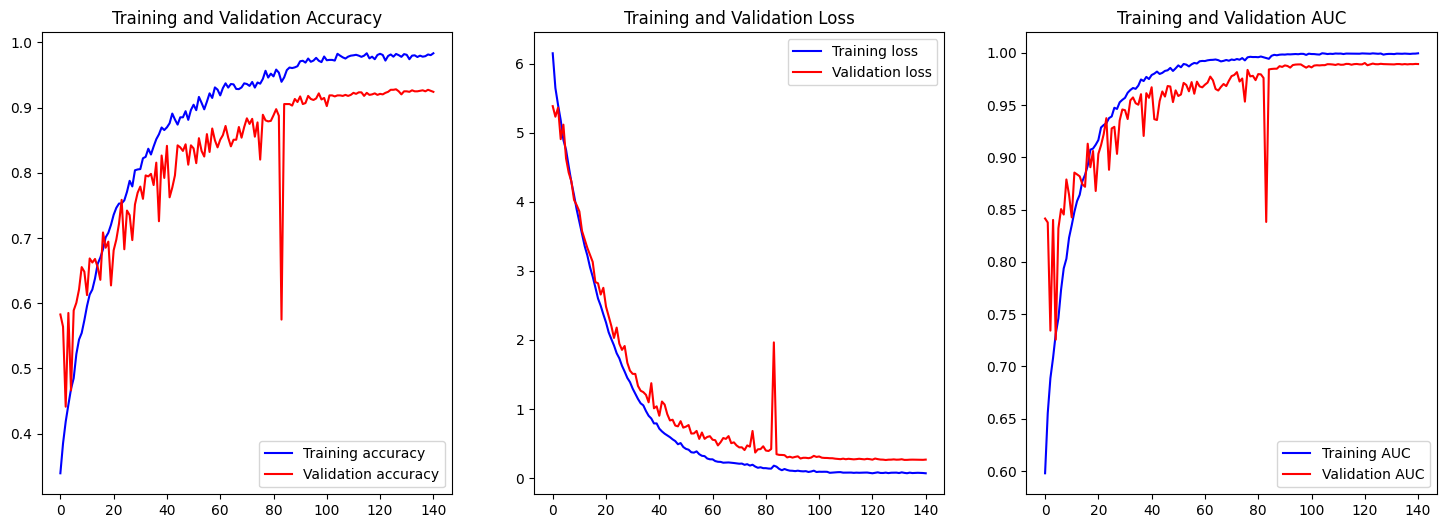

40/40 [==============================] - 5s 122ms/step - loss: 0.2587 - accuracy: 0.9281 - auc: 0.9896
Test accuracy: 0.93, Test AUC: 0.99


In [16]:
def plot_training_history(history):
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(accuracy))

    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.plot(epochs, accuracy, 'b', label='Training accuracy')
    plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.subplot(1, 3, 3)
    train_auc = history.history['auc']
    val_auc = history.history['val_auc']
    plt.plot(epochs, train_auc, 'b', label='Training AUC')
    plt.plot(epochs, val_auc, 'r', label='Validation AUC')
    plt.title('Training and Validation AUC')
    plt.legend()

    plt.show()

plot_training_history(history)

test_loss, test_accuracy, test_auc = model.evaluate(test_images, test_labels)
print(f'Test accuracy: {test_accuracy:.2f}, Test AUC: {test_auc:.2f}')

40/40 [==============================] - 5s 119ms/step


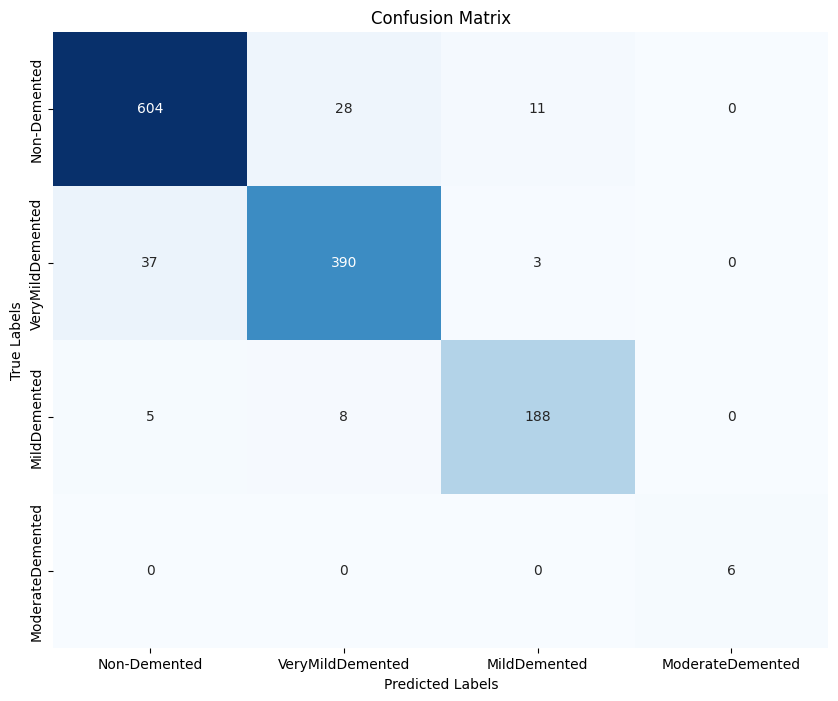

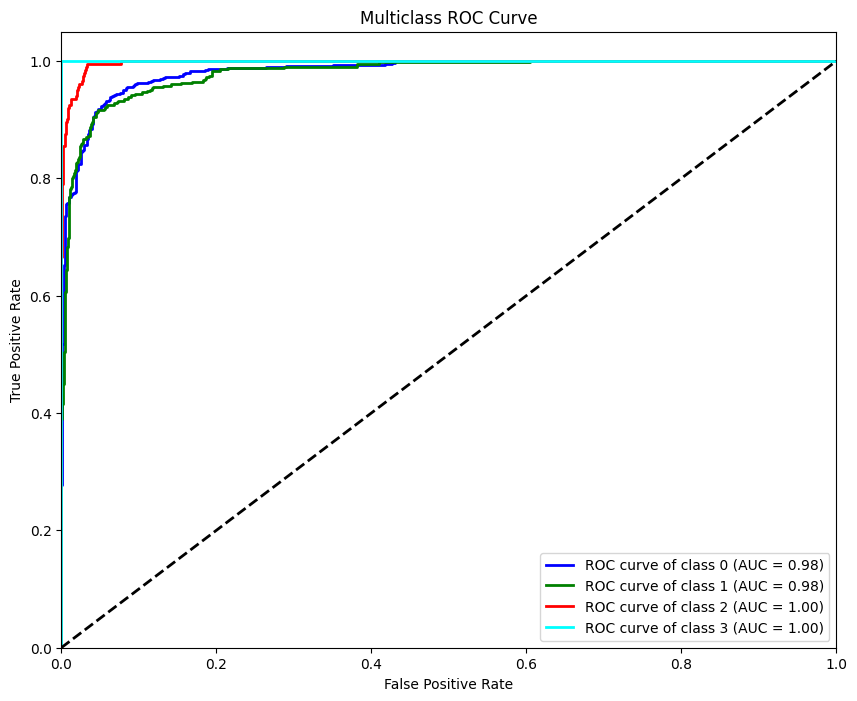

In [18]:
# test_labels = to_categorical(test_labels, num_classes=4)
from itertools import cycle

test_probabilities = model.predict(test_images)

test_predictions = np.argmax(test_probabilities, axis=1)
true_classes = np.argmax(test_labels, axis=1)

conf_matrix = confusion_matrix(true_classes, test_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Demented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented'],
            yticklabels=['Non-Demented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = 4

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels[:, i], test_probabilities[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'green', 'red', 'cyan'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (AUC = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.show()